
# **Quantum Collision Finder**

The oracle computes a toy hash function — no hardcoded collision knowledge.

Hash function (3-input bits → 2 output bits):

```
H(x2, x1, x0):
- h0 = x0 XOR x1
- h1 = x1 AND x2
```
This is a real Boolean circuit. With 3-bit inputs (8 possible values) mapping
to 2-bit outputs (4 possible values), collisions are guaranteed by pigeonhole.
The algorithm finds them without knowing which inputs collide.

Algorithm: **Grover**-based amplitude amplification over the collision space.
We search the 2D space of pairs `(a, b)` where `a < b` and `H(a) = H(b)`.

* **Goal:** Find any `(a, b)` pair where `H(a)=H(b)`
* **Search space:** 6-qubit joint register `(a, b)`
* **Oracle:** Marks States where `H(a) = H(b)`
* **Attack type:** Collision finding

In [1]:
!pip install qiskit -q
!pip install qiskit-aer -q
!pip install qiskit[visualization] -q
#!pip install qiskit-algorithms -q

# pip install qiskit-ibm-runtime
import qiskit
print("____ QISKIT VERSION____")
print(qiskit.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 58.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 70.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 74.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
____ QISKIT VERSION____
2.4.1


QUANTUM COLLISION FINDER
Hash: H(x2,x1,x0): h0=x0⊕x1, h1=x1∧x2  (3-bit→2-bit)

── Classical hash table (for verification only) ──
  H(000) = 00
  H(001) = 01
  H(010) = 01
  H(011) = 00
  H(100) = 00
  H(101) = 01
  H(110) = 11
  H(111) = 10

── True collisions (not given to oracle) ──
  H(000) = H(011) = H(100) = 00
  H(001) = H(010) = H(101) = 01

── Building quantum circuit (1 Grover iteration(s)) ──
  Qubits: 12
  Gates : 69

── Measurement results (top outcomes from 4096 shots) ──

  ✅ Valid collisions found (H(a) = H(b), a ≠ b):
    a=001(1)  b=010(2)  → H=01   shots=220
    a=000(0)  b=011(3)  → H=00   shots=203
    a=010(2)  b=101(5)  → H=01   shots=201
    a=100(4)  b=011(3)  → H=00   shots=197
    a=011(3)  b=100(4)  → H=00   shots=196
    a=011(3)  b=000(0)  → H=00   shots=195
    a=101(5)  b=010(2)  → H=01   shots=194
    a=100(4)  b=000(0)  → H=00   shots=193
    a=010(2)  b=001(1)  → H=01   shots=193
    a=001(1)  b=101(5)  → H=01   shots=182

  ⚪ Trivial (a == b) shots: 

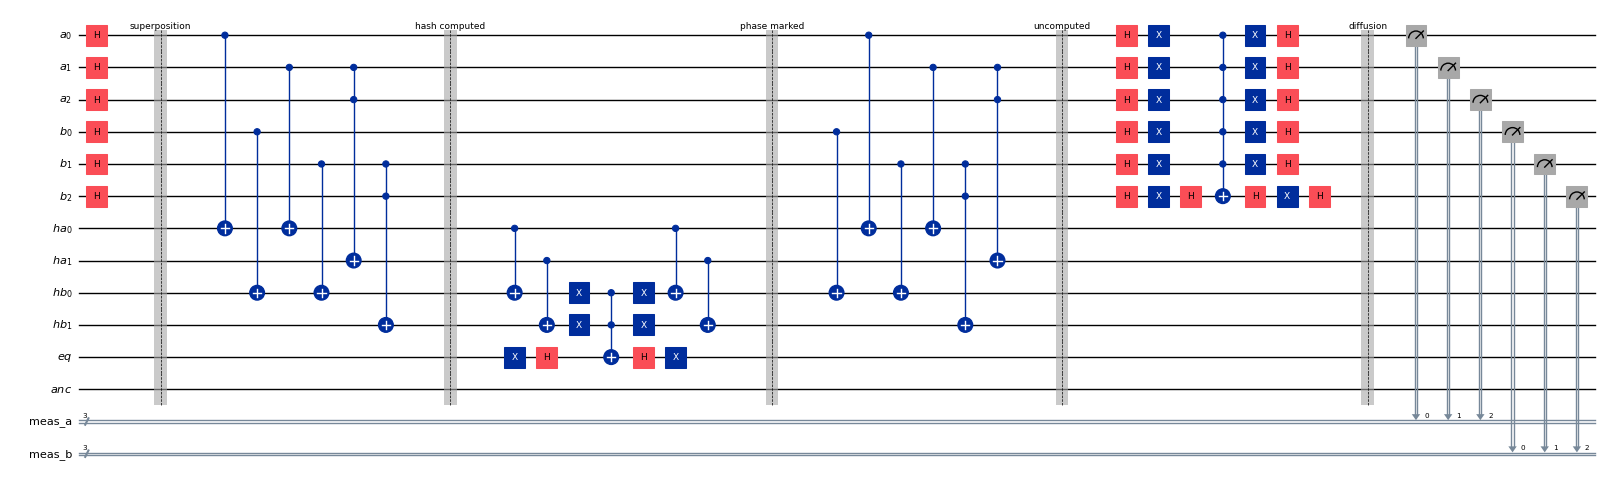

{'110 111': 6, '101 110': 1, '111 010': 2, '011 011': 222, '011 111': 2, '001 101': 169, '100 100': 211, '111 100': 7, '000 011': 195, '111 111': 193, '100 111': 3, '000 100': 193, '110 110': 193, '100 011': 196, '111 110': 2, '001 001': 194, '101 101': 194, '111 001': 1, '001 010': 193, '101 010': 201, '001 111': 6, '101 100': 6, '000 010': 3, '110 101': 2, '111 011': 1, '001 011': 5, '011 000': 203, '011 100': 197, '110 010': 4, '100 001': 6, '010 101': 194, '010 010': 196, '110 000': 2, '101 011': 16, '100 101': 5, '010 110': 2, '100 000': 179, '100 110': 5, '010 000': 5, '011 101': 6, '011 010': 3, '000 001': 5, '010 001': 220, '000 110': 5, '000 000': 199, '011 110': 2, '111 000': 3, '100 010': 3, '010 100': 3, '110 001': 3, '000 111': 5, '110 011': 6, '000 101': 4, '001 100': 6, '001 000': 4, '111 101': 5, '010 011': 2, '011 001': 4, '101 000': 4, '001 110': 4, '110 100': 2, '101 001': 182, '101 111': 1}


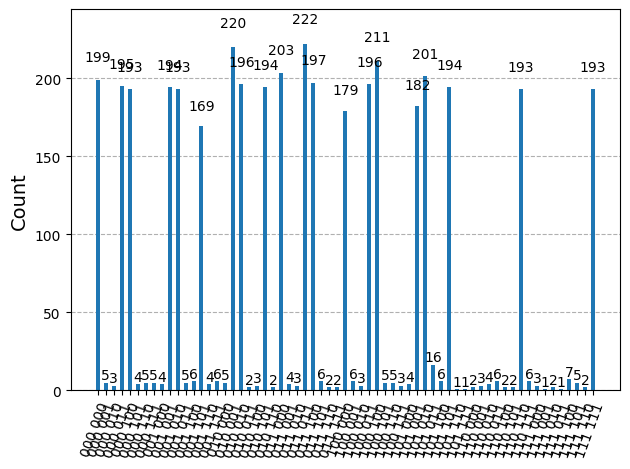

In [4]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.circuit.library import MCMT
from collections import defaultdict
import itertools

# ── 1. Classical reference: compute the hash for all inputs ──────────────────

def toy_hash(x: int, n_input_bits: int = 3) -> int:
  '''
  Toy hash: 3-bit input → 2-bit output.
  h0 = x0 XOR x1
  h1 = x1 AND x2
  '''
  x0 = (x >> 0) & 1
  x1 = (x >> 1) & 1
  x2 = (x >> 2) & 1
  h0 = x0 ^ x1
  h1 = x1 & x2
  return (h1 << 1) | h0

def find_all_collisions_classically(n_input_bits=3):
  '''Enumerate all collisions — used only for verification, not for oracle design.'''
  hash_map = defaultdict(list)
  for x in range(2**n_input_bits):
    hash_map[toy_hash(x)].append(x)
  collisions = {h: inputs for h, inputs in hash_map.items() if len(inputs) > 1}
  return collisions

# ── 2. Build the hash oracle as a real quantum circuit ───────────────────────

def build_hash_oracle(qc: QuantumCircuit,
  x_qubits: list,
  hash_qubits: list,
  ancilla_qubits: list):
  '''
  Implements H(x2, x1, x0) into hash_qubits using only quantum gates.
  The oracle knows NOTHING about collisions — it just computes the hash.


  Registers:
    x_qubits[0] = x0 (LSB)
    x_qubits[1] = x1
    x_qubits[2] = x2 (MSB)
    hash_qubits[0] = h0 output  (h0 = x0 XOR x1)
    hash_qubits[1] = h1 output  (h1 = x1 AND x2)
    ancilla_qubits[0] = scratch for AND gate
  '''
  # h0 = x0 XOR x1  →  CNOT(x0→h0), CNOT(x1→h0)
  qc.cx(x_qubits[0], hash_qubits[0])
  qc.cx(x_qubits[1], hash_qubits[0])

  # h1 = x1 AND x2  →  Toffoli(x1, x2 → h1)
  qc.ccx(x_qubits[1], x_qubits[2], hash_qubits[1])


def uncompute_hash_oracle(qc, x_qubits, hash_qubits, ancilla_qubits):
  '''Uncomputes the hash (oracle is its own inverse for this circuit).'''
  build_hash_oracle(qc, x_qubits, hash_qubits, ancilla_qubits)

# ── 3. Collision-finding circuit ─────────────────────────────────────────────

def build_collision_circuit(n_grover_iterations: int = 1):
  '''
  Searches for pairs (a, b) with H(a) = H(b) and a ≠ b.

  ```
  Strategy:
    - Allocate two input registers A and B (3 bits each)
    - Allocate two hash output registers HA and HB (2 bits each)
    - Compute H(A) → HA  and  H(B) → HB  using the real oracle
    - Use a phase-kickback trick: flip a phase-flag qubit when HA == HB
    - Uncompute the hash registers (keep circuit clean)
    - Apply Grover diffusion on the A and B registers
    - Measure A and B

  This genuinely searches without knowing collision pairs.
  '''
  n_x = 3   # input bits per register
  n_h = 2   # hash output bits

  # Registers
  reg_a   = QuantumRegister(n_x, name='a')      # first input
  reg_b   = QuantumRegister(n_x, name='b')      # second input
  reg_ha  = QuantumRegister(n_h, name='ha')     # H(a)
  reg_hb  = QuantumRegister(n_h, name='hb')     # H(b)
  reg_eq  = QuantumRegister(1,   name='eq')     # equality flag
  reg_anc = QuantumRegister(1,   name='anc')    # ancilla
  creg_a  = ClassicalRegister(n_x, name='meas_a')
  creg_b  = ClassicalRegister(n_x, name='meas_b')

  qc = QuantumCircuit(reg_a, reg_b, reg_ha, reg_hb, reg_eq, reg_anc,
                      creg_a, creg_b)

  # ── Step 1: Equal superposition over all (a, b) pairs ───────────────────
  qc.h(reg_a)
  qc.h(reg_b)
  qc.barrier(label="superposition")

  for _ in range(n_grover_iterations):
      # ── Step 2: Compute H(a) and H(b) with the real oracle ──────────────
      build_hash_oracle(qc, list(reg_a), list(reg_ha), list(reg_anc))
      build_hash_oracle(qc, list(reg_b), list(reg_hb), list(reg_anc))
      qc.barrier(label="hash computed")

      # ── Step 3: Phase flip when H(a) == H(b) ────────────────────────────
      # We mark states where ha == hb by flipping the eq qubit,
      # then kick back a phase via eq in |−⟩, then unflip eq.

      # Prepare eq qubit in |−⟩ for phase kickback
      qc.x(reg_eq[0])
      qc.h(reg_eq[0])

      # eq flips iff ha[0]==hb[0] AND ha[1]==hb[1]
      # "equal" on bit i ↔ XNOR(ha_i, hb_i) ↔ NOT(ha_i XOR hb_i)
      # We implement: flip eq if ha XOR hb == 00
      # Step 3a: compute XOR of each hash bit into hb (hb becomes ha XOR hb)
      qc.cx(reg_ha[0], reg_hb[0])
      qc.cx(reg_ha[1], reg_hb[1])

      # Step 3b: flip hb bits (now hb[i] = 1 iff ha[i]==hb[i])
      qc.x(reg_hb[0])
      qc.x(reg_hb[1])

      # Step 3c: Toffoli chain — flip eq iff both hb bits are 1
      # (i.e., both hash bits agree)
      qc.ccx(reg_hb[0], reg_hb[1], reg_eq[0])

      # Step 3d: uncompute hb back to H(b)
      qc.x(reg_hb[0])
      qc.x(reg_hb[1])
      qc.cx(reg_ha[0], reg_hb[0])
      qc.cx(reg_ha[1], reg_hb[1])

      # Undo eq superposition (phase was kicked back; eq returns to |1⟩→|0⟩)
      qc.h(reg_eq[0])
      qc.x(reg_eq[0])
      qc.barrier(label="phase marked")

      # ── Step 4: Uncompute hash registers ────────────────────────────────
      uncompute_hash_oracle(qc, list(reg_b), list(reg_hb), list(reg_anc))
      uncompute_hash_oracle(qc, list(reg_a), list(reg_ha), list(reg_anc))
      qc.barrier(label="uncomputed")

      # ── Step 5: Grover diffusion on (a, b) ──────────────────────────────
      # D = 2|s><s| - I  over the 6-qubit joint space
      all_ab = list(reg_a) + list(reg_b)
      qc.h(all_ab)
      qc.x(all_ab)
      # Multi-controlled Z (phase flip on |000000⟩)
      qc.h(all_ab[-1])
      qc.mcx(all_ab[:-1], all_ab[-1])
      qc.h(all_ab[-1])
      qc.x(all_ab)
      qc.h(all_ab)
      qc.barrier(label="diffusion")

  # ── Step 6: Measure ─────────────────────────────────────────────────────
  qc.measure(reg_a, creg_a)
  qc.measure(reg_b, creg_b)

  return qc


# ── 4. Run and interpret ─────────────────────────────────────────────────────

def run_collision_search(n_grover_iterations=1, shots=4096):
  print("=" * 60)
  print("QUANTUM COLLISION FINDER")
  print("Hash: H(x2,x1,x0): h0=x0⊕x1, h1=x1∧x2  (3-bit→2-bit)")
  print("=" * 60)


  # Show the full hash table (classical reference only)
  print("\n── Classical hash table (for verification only) ──")
  hash_map = defaultdict(list)
  for x in range(8):
      h = toy_hash(x)
      b = format(x, '03b')
      print(f"  H({b}) = {format(h, '02b')}")
      hash_map[h].append(x)

  print("\n── True collisions (not given to oracle) ──")
  for h, xs in sorted(hash_map.items()):
      if len(xs) > 1:
          inputs = [format(x, '03b') for x in xs]
          print(f"  H({') = H('.join(inputs)}) = {format(h, '02b')}")

  # Build and run the circuit
  print(f"\n── Building quantum circuit ({n_grover_iterations} Grover iteration(s)) ──")
  qc = build_collision_circuit(n_grover_iterations)
  print(f"  Qubits: {qc.num_qubits}")
  print(f"  Gates : {sum(qc.count_ops().values())}")

  simulator = AerSimulator()
  job = simulator.run(qc, shots=shots)
  result = job.result()
  counts = result.get_counts()

  # Parse and filter results
  print(f"\n── Measurement results (top outcomes from {shots} shots) ──")
  collision_counts = defaultdict(int)
  trivial_counts   = defaultdict(int)  # a == b

  for bitstring, count in counts.items():
      # Qiskit returns creg_b creg_a  (right-to-left register order)
      parts = bitstring.split()
      if len(parts) == 2:
          b_str, a_str = parts[0], parts[1]
      else:
          combined = bitstring.replace(' ', '')
          a_str = combined[:3]
          b_str = combined[3:]

      a = int(a_str, 2)
      b = int(b_str, 2)

      if a == b:
          trivial_counts[(a, b)] += count
      elif toy_hash(a) == toy_hash(b):
          collision_counts[(a, b)] += count

  # Sort by frequency
  sorted_collisions = sorted(collision_counts.items(), key=lambda x: -x[1])
  sorted_trivial    = sorted(trivial_counts.items(),   key=lambda x: -x[1])

  print(f"\n  ✅ Valid collisions found (H(a) = H(b), a ≠ b):")
  if sorted_collisions:
      for (a, b), cnt in sorted_collisions[:10]:
          ha = toy_hash(a)
          print(f"    a={format(a,'03b')}({a})  b={format(b,'03b')}({b})"
                f"  → H={format(ha,'02b')}   shots={cnt}")
  else:
      print("    (none — try more Grover iterations or shots)")

  print(f"\n  ⚪ Trivial (a == b) shots: {sum(trivial_counts.values())}")
  print(f"  ✅ Collision shots       : {sum(collision_counts.values())}")
  print(f"  ❌ Non-collision shots   : "
        f"{shots - sum(collision_counts.values()) - sum(trivial_counts.values())}")

  # Confirm the oracle never received collision info
  print("\n── Verification ──")
  print("  The oracle only implements gates for:")
  print("    CNOT(x0→h0), CNOT(x1→h0)   [computes h0 = x0 XOR x1]")
  print("    CCX(x1, x2 → h1)           [computes h1 = x1 AND x2]")
  print("  No collision pair was hardcoded anywhere.")

  return qc, counts


# ── 5. Entry point ───────────────────────────────────────────────────────────

if __name__ == "__main__":
  qc, counts = run_collision_search(n_grover_iterations=1, shots=4096)


# Optionally draw the circuit (text mode)
#print(qc.draw(output='text', fold=120))
display(qc.draw(output='mpl', scale=0.5, fold= 100, plot_barriers=True))
#qc.draw(output='mpl', filename="/content/A01_GROVER_1st_preimageAttack.png", scale=2.5, fold=200, plot_barriers=True)

print(counts)
from qiskit.visualization import plot_histogram
plot_histogram(counts)
